# NFL Defensive Combine Analytics

**Research question:** How well do combine measurables and draft capital predict NFL career success for defensive prospects?

**Data:** NFL Combine, 2000–2018 · Analysis uses defensive positions with PFR-linked career AV where noted.

## Phase 1: Clean defensive dataset

**Goal:** Filter to defensive positions and add `was_drafted` and `has_pfr_id` flags.

**Output:** `df_def` (2,780 rows), `df_analysis` (2,298 PFR-linked rows for AV analysis), `defensive_combine_clean.csv`

In [ ]:
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", 40)
pd.set_option("display.expand_frame_repr", False)

_csv_name = "combine_data_since_2000_PROCESSED_2018-04-26.csv"
_here = Path.cwd().resolve()
_csv = next(
    (base / ":data" / _csv_name for base in (_here, *_here.parents) if (base / ":data" / _csv_name).is_file()),
    None,
)
if _csv is None:
    raise FileNotFoundError(f"Could not locate :data/{_csv_name} (cwd={_here})")

df = pd.read_csv(_csv)

print("shape (rows, cols):", df.shape)
print("columns:", list(df.columns))
df.head(15)

df.info()
df.describe()

shape (rows, cols): (6218, 16)
columns: ['Player', 'Pos', 'Ht', 'Wt', 'Forty', 'Vertical', 'BenchReps', 'BroadJump', 'Cone', 'Shuttle', 'Year', 'Pfr_ID', 'AV', 'Team', 'Round', 'Pick']


<bound method NDFrame.describe of                 Player   Pos  Ht   Wt  Forty  Vertical  BenchReps  BroadJump  Cone  Shuttle  Year    Pfr_ID    AV                Team  Round   Pick
0         John Abraham   OLB  76  252   4.55       NaN        NaN        NaN   NaN      NaN  2000  AbraJo00  26.0       New York Jets    1.0   13.0
1      Shaun Alexander    RB  72  218   4.58       NaN        NaN        NaN   NaN      NaN  2000  AlexSh00  26.0    Seattle Seahawks    1.0   19.0
2       Darnell Alford    OT  76  334   5.56      25.0       23.0       94.0  8.48     4.98  2000  AlfoDa20   0.0  Kansas City Chiefs    6.0  188.0
3         Kyle Allamon    TE  74  253   4.97      29.0        NaN      104.0  7.29     4.49  2000       NaN   0.0                 NaN    NaN    NaN
4     Rashard Anderson    CB  74  206   4.55      34.0        NaN      123.0  7.18     4.15  2000  AndeRa21   6.0   Carolina Panthers    1.0   23.0
...                ...   ...  ..  ...    ...       ...        ...        ...  

In [26]:
DEF_POS = ["DE", "DT", "NT", "EDGE", "OLB", "ILB", "LB", "CB", "DB", "S", "FS", "SS"]

df_def = df[df["Pos"].isin(DEF_POS)].copy()
print("defensive rows:", len(df_def))
df_def["Pos"].value_counts()

defensive rows: 2780


Pos
CB      630
DE      487
DT      463
OLB     424
ILB     276
FS      229
SS      213
S        27
EDGE     23
NT        3
LB        3
DB        2
Name: count, dtype: int64

In [27]:
df_def["was_drafted"] = df_def["Round"].notna()
df_def["has_pfr_id"] = df_def["Pfr_ID"].notna()

print(df_def[["was_drafted", "has_pfr_id"]].mean().round(3))

was_drafted    0.657
has_pfr_id     0.827
dtype: float64


In [28]:
df_analysis = df_def[df_def["has_pfr_id"]].copy()
print("rows for AV analysis:", len(df_analysis))

rows for AV analysis: 2298


In [29]:
miss_pct = (df_def.isna().mean() * 100).sort_values(ascending=False)
miss_pct[miss_pct > 0].round(1)

Cone         35.5
Pick         34.3
Round        34.3
Team         34.3
Shuttle      34.2
BenchReps    21.7
BroadJump    21.0
Vertical     20.9
Pfr_ID       17.3
Forty         2.2
dtype: float64

In [30]:
df_def.head()
df_def.info()

<class 'pandas.DataFrame'>
Index: 2780 entries, 0 to 6217
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player       2780 non-null   str    
 1   Pos          2780 non-null   str    
 2   Ht           2780 non-null   int64  
 3   Wt           2780 non-null   int64  
 4   Forty        2719 non-null   float64
 5   Vertical     2198 non-null   float64
 6   BenchReps    2176 non-null   float64
 7   BroadJump    2197 non-null   float64
 8   Cone         1793 non-null   float64
 9   Shuttle      1830 non-null   float64
 10  Year         2780 non-null   int64  
 11  Pfr_ID       2298 non-null   str    
 12  AV           2780 non-null   float64
 13  Team         1827 non-null   str    
 14  Round        1827 non-null   float64
 15  Pick         1827 non-null   float64
 16  was_drafted  2780 non-null   bool   
 17  has_pfr_id   2780 non-null   bool   
dtypes: bool(2), float64(9), int64(3), str(4)
memory usage: 374.6 KB


In [31]:
out = _csv.parent / "defensive_combine_clean.csv"
df_def.to_csv(out, index=False)
print("Saved to", out)

Saved to /Users/jorgegonzalez/Desktop/nfl-defensive-analytics/:data/defensive_combine_clean.csv


## Phase 2: Career AV by draft round

**Cohort:** Defensive players with PFR id (`df_analysis`), drafted only for the chart.

**Metric:** Mean career Approximate Value (AV) by draft round.

In [32]:
import matplotlib.pyplot as plt

drafted = df_analysis[df_analysis["was_drafted"]].copy()

by_round = (
    drafted.groupby("Round", as_index=False)["AV"]
    .agg(mean_av="mean", player_count="count")
    .sort_values("Round")
)

by_round

,Round,mean_av,player_count
0,1.0,16.270548,292
1,2.0,10.744898,294
2,3.0,7.046980,298
3,4.0,6.415162,277
4,5.0,4.868852,244
5,6.0,3.762626,198
6,7.0,3.502646,189


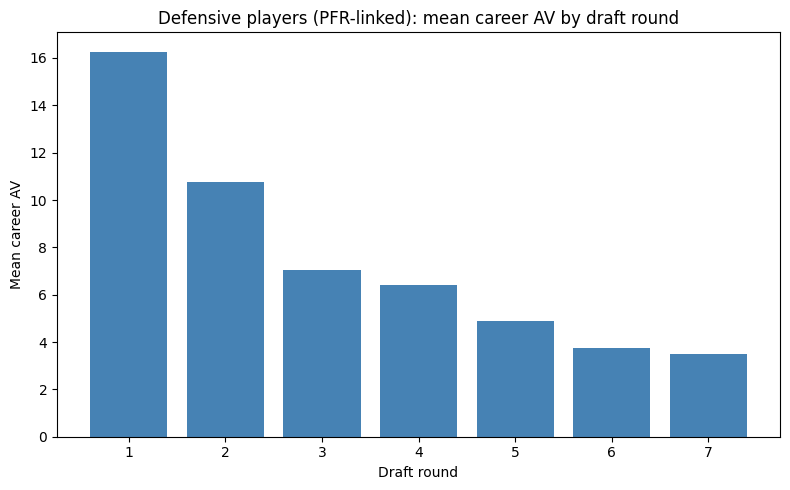

In [33]:
plt.figure(figsize=(8, 5))
plt.bar(by_round["Round"].astype(int), by_round["mean_av"], color="steelblue")
plt.xlabel("Draft round")
plt.ylabel("Mean career AV")
plt.title("Defensive players (PFR-linked): mean career AV by draft round")
plt.xticks(by_round["Round"].astype(int))
plt.tight_layout()
plt.show()

**Takeaway:** Round 1 defenders average about **16.3** career AV; Round 7 averages about **3.5**. Undrafted players in this cohort average about **1.6**. Draft round is strongly associated with career AV in this dataset.

### Additional context: Undrafted players

Players in `df_analysis` without draft round data. Not included in the round-by-round chart above.

In [34]:
undrafted = df_analysis[~df_analysis["was_drafted"]]
print("Undrafted count:", len(undrafted))
print("Undrafted mean AV:", undrafted["AV"].mean().round(2))

Undrafted count: 506
Undrafted mean AV: 1.63
